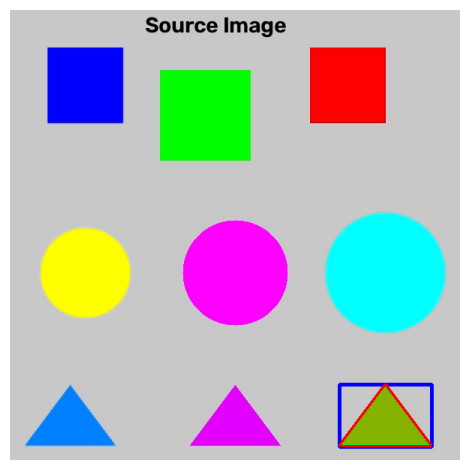

In [44]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('template_match_src.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

cnt = contours[1]  #取第一个轮廓

#计算面积和周长
area = cv2.contourArea(cnt)
perimeter = cv2.arcLength(cnt, True)  #true表示轮廓闭合

#边界框（先计算轮廓最小外接矩形，再将矩形绘制在原图上）
x, y, w, h = cv2.boundingRect(cnt)
cv2.rectangle(img, (x, y), (x+w, y+h), (0, 0, 255), 3)


#轮廓检测（多边形拟合）
#epsilon是近似精度，通常为周长的百分比
epsilon = 0.01*perimeter
approx = cv2.approxPolyDP(cnt, epsilon, True)  #对轮廓进行多边近似
cv2.polylines(img, [approx], True, (0, 255, 0), 2)  #在图像上绘制多边线条

hull = cv2.convexHull(cnt)
cv2.polylines(img, [hull], True, (255, 0, 0), 2)

plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

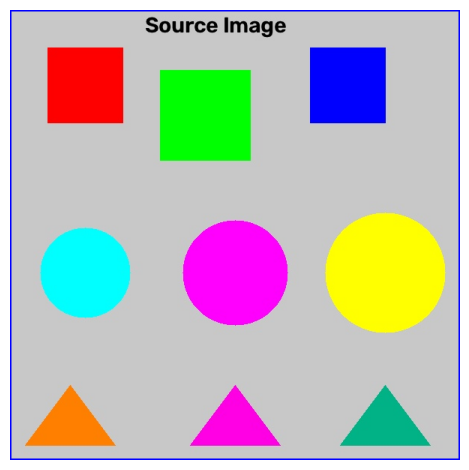

In [46]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('template_match_src.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# 提取所有轮廓
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 【核心修改】复制原图，并用 for 循环遍历每一个检测到的轮廓
draw_img = img.copy()

for cnt in contours:
    # 1. 过滤掉太小的轮廓（避免噪点干扰）
    area = cv2.contourArea(cnt)
    if area < 100:  # 面积小于100的直接跳过
        continue
    
    # 2. 计算周长
    perimeter = cv2.arcLength(cnt, True)
    
    # 3. 绘制边界框
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(draw_img, (x, y), (x+w, y+h), (0, 0, 255), 2)
    
    # 4. 绘制多边形拟合
    epsilon = 0.02 * perimeter
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    cv2.polylines(draw_img, [approx], True, (0, 255, 0), 2)
    
    # 5. 绘制凸包
    hull = cv2.convexHull(cnt)
    cv2.polylines(draw_img, [hull], True, (255, 0, 0), 2)

# 6. 统一显示结果
img_rgb = cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.tight_layout()
plt.show()

基于饱和度检测到 9 个独立轮廓


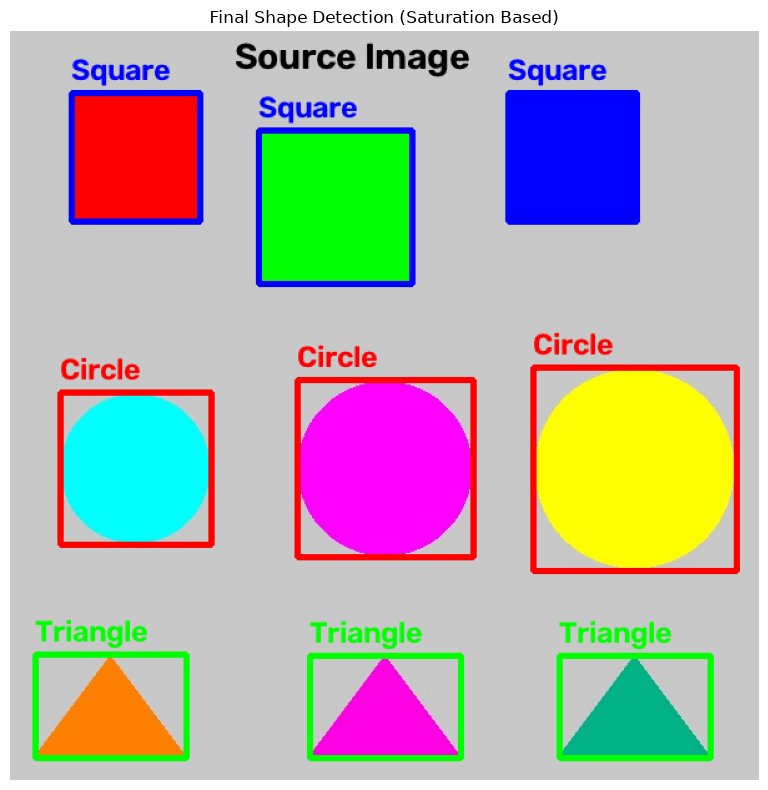

In [59]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. 读取图片并转换到 HSV 颜色空间
img = cv2.imread('template_match_src.jpg')
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# 关键修复1：提取“饱和度(Saturation)”通道作为掩膜
# 饱和度的范围是 0-255。图形是纯色的，饱和度高（>50）；背景和文字饱和度很低
_, binary = cv2.threshold(hsv[:, :, 1], 50, 255, cv2.THRESH_BINARY)

# 关键修复2：形态学闭运算，填补图形内部可能存在的微小噪点
kernel = np.ones((3, 3), np.uint8)
binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)

# 查找轮廓
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 打印当前检测到的轮廓数量
print(f"基于饱和度检测到 {len(contours)} 个独立轮廓")

# 2. 遍历并绘制结果
draw_img = img.copy()

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 500:  # 过滤掉更小的干扰项
        continue
    
    perimeter = cv2.arcLength(cnt, True)
    # 使用统一的 epsilon，因为饱和度分割出来的边缘已经很干净了
    epsilon = 0.04 * perimeter
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    vertices = len(approx)
    
    x, y, w, h = cv2.boundingRect(cnt)
    
    # 形状分类
    if vertices == 3:
        shape_name = "Triangle"
        color = (0, 255, 0)  # 绿色
    elif vertices == 4:
        shape_name = "Square"
        color = (255, 0, 0)  # 蓝色
    else:
        shape_name = "Circle"
        color = (0, 0, 255)  # 红色
    
    cv2.rectangle(draw_img, (x, y), (x+w, y+h), color, 3)
    cv2.putText(draw_img, shape_name, (x, y-10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 3)

# 3. 显示结果
img_rgb = cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.title('Final Shape Detection (Saturation Based)')
plt.axis('off')
plt.tight_layout()
plt.show()